# Evaluating health hazards in relation to 911 EMS calls

General pollution and overall impact on health. In combination with additional environmental and systemic factors like education, linguistic isolation, poverty. 
Could evaluate how that impacts demographics.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, date
import geopandas as gpd
import numpy as np
from shapely import wkt
from scipy.spatial import cKDTree
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import re

In [2]:
emergency = pd.read_csv("Fire_Department_and_Emergency_Medical_Services_Dispatched_Calls_for_Service_20260315.csv")

In [3]:
emergency.columns

Index(['Call Number', 'Unit ID', 'Incident Number', 'Call Type', 'Call Date',
       'Received DtTm', 'Entry DtTm', 'Dispatch DtTm', 'Response DtTm',
       'On Scene DtTm', 'Transport DtTm', 'Hospital DtTm',
       'Call Final Disposition', 'Available DtTm', 'Address', 'City',
       'Zipcode of Incident', 'Battalion', 'Station Area', 'Original Priority',
       'Priority', 'Final Priority', 'ALS Unit', 'Call Type Group',
       'Number of Alarms', 'Unit Type', 'Unit sequence in call dispatch',
       'Fire Prevention District', 'Supervisor District',
       'Neighborhooods - Analysis Boundaries', 'RowID', 'case_location'],
      dtype='str')

In [4]:
emergency['Call Date']

0         12/31/2024
1         12/31/2024
2         12/31/2024
3         12/31/2024
4         12/31/2024
             ...    
368895    12/30/2025
368896    12/30/2025
368897    12/30/2025
368898    12/30/2025
368899    12/30/2025
Name: Call Date, Length: 368900, dtype: str

In [5]:
emergency.head()

,Call Number,Unit ID,Incident Number,Call Type,Call Date,Received DtTm,Entry DtTm,Dispatch DtTm,Response DtTm,On Scene DtTm,...,ALS Unit,Call Type Group,Number of Alarms,Unit Type,Unit sequence in call dispatch,Fire Prevention District,Supervisor District,Neighborhooods - Analysis Boundaries,RowID,case_location
0,243661857,AM215,24183023,Medical Incident,12/31/2024,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,...,False,Non Life-threatening,1,BLS,1.0,3.0,5.0,Tenderloin,243661857-AM215,POINT (-122.411015164 37.78418755)
1,243660122,E36,24182744,Other,12/31/2024,2024 Dec 31 01:36:29 AM,2024 Dec 31 01:36:29 AM,2024 Dec 31 01:36:58 AM,2024 Dec 31 01:39:59 AM,2024 Dec 31 01:40:54 AM,...,True,Alarm,1,ENGINE,1.0,2.0,5.0,Hayes Valley,243660122-E36,POINT (-122.42105326 37.775695233)
2,243660122,B02,24182744,Other,12/31/2024,2024 Dec 31 01:36:29 AM,2024 Dec 31 01:36:29 AM,2024 Dec 31 01:36:58 AM,2024 Dec 31 01:39:02 AM,2024 Dec 31 01:41:31 AM,...,False,Alarm,1,CHIEF,2.0,2.0,5.0,Hayes Valley,243660122-B02,POINT (-122.42105326 37.775695233)
3,243660212,E05,24182765,Medical Incident,12/31/2024,2024 Dec 31 03:17:09 AM,2024 Dec 31 03:18:29 AM,2024 Dec 31 03:18:36 AM,2024 Dec 31 03:20:52 AM,2024 Dec 31 03:22:55 AM,...,True,Potentially Life-Threatening,1,ENGINE,1.0,4.0,5.0,Japantown,243660212-E05,POINT (-122.434729992 37.784944006)
4,243660148,M576,24182750,Medical Incident,12/31/2024,2024 Dec 31 02:06:51 AM,2024 Dec 31 02:09:38 AM,2024 Dec 31 02:10:26 AM,2024 Dec 31 02:10:33 AM,2024 Dec 31 02:23:11 AM,...,True,Potentially Life-Threatening,1,MEDIC,2.0,10.0,10.0,Bayview Hunters Point,243660148-M576,POINT (-122.367922359 37.727398351)


In [6]:
med_inc = emergency[emergency['Call Type']=='Medical Incident']
len(med_inc)

241317

In [7]:
med_inc_day = med_inc[med_inc['Call Date']=='01/05/2025']

/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_57273/2893423595.py:8: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  sf_map.plot(ax=ax, color='white', edgecolor='black', column='neighborhood')


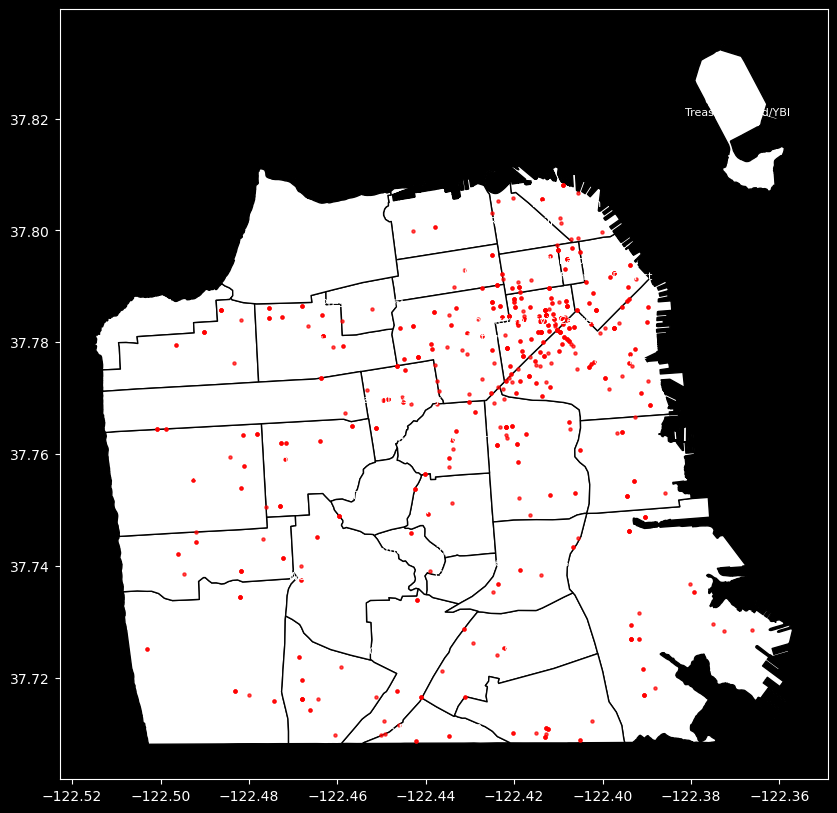

In [8]:
# Load SF Neighborhood Boundaries
sf_map = gpd.read_file('Planning_Neighborhood_Groups_Map_20260402.csv')
sf_map['geometry'] = sf_map['the_geom'].apply(wkt.loads)
sf_map = gpd.GeoDataFrame(sf_map, geometry='geometry', crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(10, 10))

sf_map.plot(ax=ax, color='white', edgecolor='black', column='neighborhood')
sf_map_proj = sf_map.to_crs(epsg=3857)
centroids = sf_map_proj.geometry.centroid.to_crs(sf_map.crs)
for x, y, label in zip(centroids.x, centroids.y, sf_map['neighborho']):
    ax.text(x, y, label, fontsize=8, ha='center')

med_inc_day = med_inc_day.dropna(subset=['case_location'])
med_inc_day['geometry'] = med_inc_day['case_location'].apply(wkt.loads)
med_inc_gdf = gpd.GeoDataFrame(med_inc_day, geometry='geometry', crs="EPSG:4326")

med_inc_gdf.plot(ax=ax, color='red', markersize=5, alpha=0.7, label='Emergency Calls')
plt.show()

/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_57273/1496964625.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  zip_centroids = med_inc_gdf.dissolve(by='Zipcode of Incident').centroid


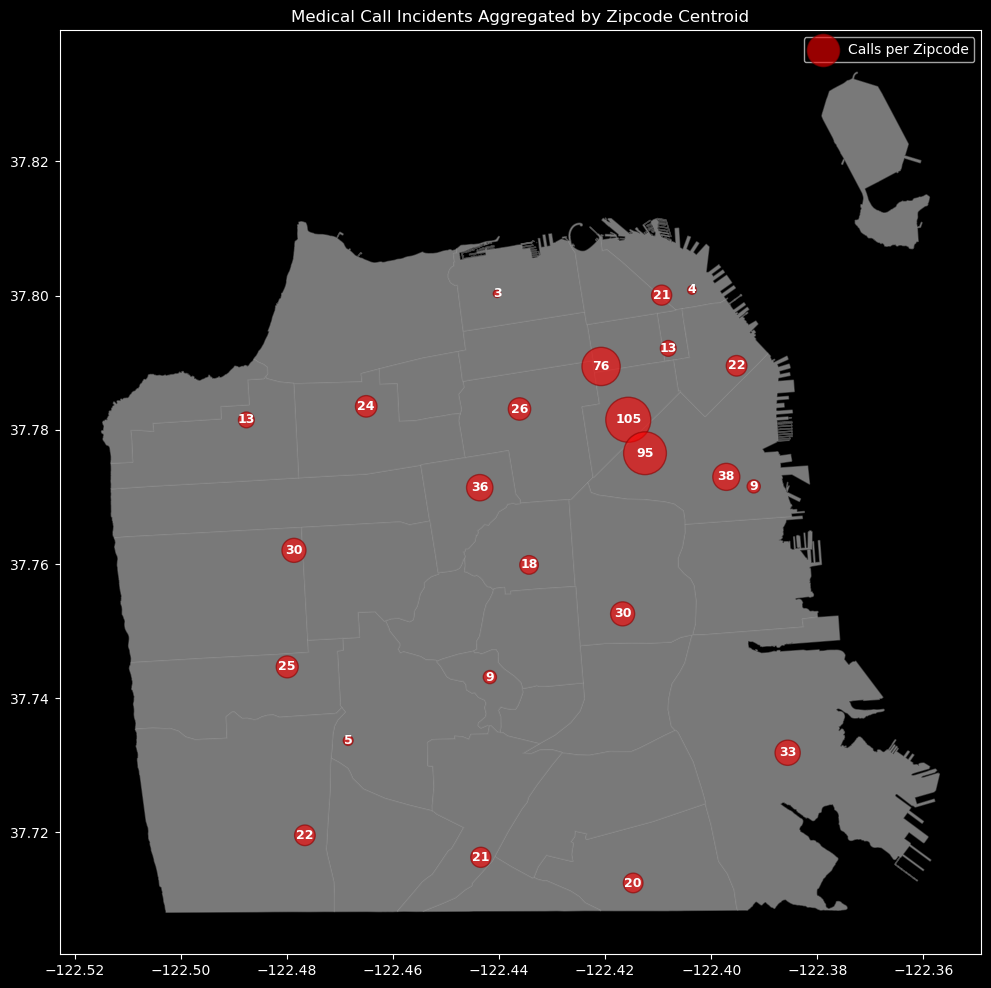

In [9]:
# Aggregate by Zipcode
med_inc_day = med_inc_day.dropna(subset=['case_location'])
med_inc_day['geometry'] = med_inc_day['case_location'].apply(wkt.loads)
med_inc_gdf = gpd.GeoDataFrame(med_inc_day, geometry='geometry', crs="EPSG:4326")

zip_counts = med_inc_gdf.groupby('Zipcode of Incident').size().reset_index(name='call_count')

zip_centroids = med_inc_gdf.dissolve(by='Zipcode of Incident').centroid
zip_summary = gpd.GeoDataFrame(zip_counts, geometry=zip_centroids[zip_counts['Zipcode of Incident']].values, crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(12, 12))
sf_map.plot(ax=ax, color='#f2f2f2', edgecolor='grey', alpha=0.5)

zip_summary.plot(
    ax=ax, 
    color='red', 
    markersize=zip_summary['call_count'] * 10, 
    alpha=0.6, 
    edgecolor='darkred',
    label='Calls per Zipcode'
)

for x, y, label in zip(zip_summary.geometry.x, zip_summary.geometry.y, zip_summary['call_count']):
    ax.text(x, y, str(label), fontsize=9, fontweight='bold', ha='center', va='center')

plt.title('Medical Call Incidents Aggregated by Zipcode Centroid')
plt.legend()
plt.show()

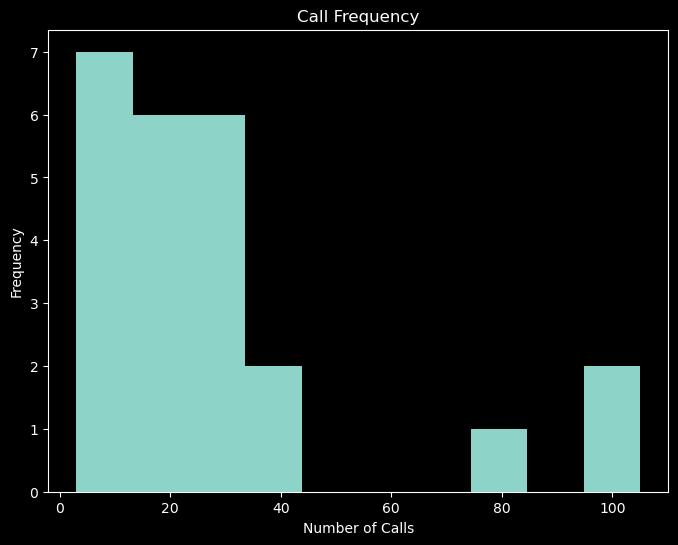

In [10]:
zip_counts['call_count'].hist(bins=10, grid=False, figsize=(8,6))
plt.title('Call Frequency')
plt.ylabel('Frequency')
plt.xlabel('Number of Calls')
plt.show()

In [11]:
print(f"mean: {zip_counts['call_count'].mean()}", 
        f"variance: {zip_counts['call_count'].var()}")

mean: 29.083333333333332 variance: 702.427536231884


In [12]:
hazards_all = pd.read_excel("calenviroscreen40resultsdatadictionary_F_2021.xlsx", sheet_name=None)
hazards = hazards_all['CES4.0FINAL_results']
demographics = hazards_all['Demographic Profile']
dictionary = hazards_all['Data Dictionary']

In [13]:
hazards.head()

,Census Tract,Total Population,California County,ZIP,Approximate Location,Longitude,Latitude,CES 4.0 Score,CES 4.0 Percentile,CES 4.0 Percentile Range,...,Linguistic Isolation Pctl,Poverty,Poverty Pctl,Unemployment,Unemployment Pctl,Housing Burden,Housing Burden Pctl,Pop. Char.,Pop. Char. Score,Pop. Char. Pctl
0,6019001100,2780,Fresno,93706,Fresno,-119.781696,36.709695,93.183570,100.000000,95-100% (highest scores),...,79.374746,76.0,98.919598,12.8,93.831338,30.3,91.039290,93.155109,9.663213,99.722642
1,6077000700,4680,San Joaquin,95206,Stockton,-121.287873,37.943173,86.653790,99.987393,95-100% (highest scores),...,95.533902,73.2,98.391960,19.8,99.206143,31.2,92.281369,93.165408,9.664281,99.735250
2,6037204920,2751,Los Angeles,90023,Los Angeles,-118.197497,34.017500,82.393909,99.974786,95-100% (highest scores),...,81.553661,62.6,93.391960,6.4,61.530453,20.3,63.967047,83.751814,8.687785,95.789208
3,6019000700,3664,Fresno,93706,Fresno,-119.827707,36.734535,81.327940,99.962179,95-100% (highest scores),...,78.711598,65.7,95.351759,15.7,97.345133,35.4,96.413181,94.641227,9.817371,99.886536
4,6019000200,2689,Fresno,93706,Fresno,-119.805504,36.735491,80.745476,99.949571,95-100% (highest scores),...,86.561104,72.7,98.304020,13.7,95.288912,32.7,94.157161,95.398873,9.895964,99.949571


In [14]:
# Clean demographics column headers
demographics.columns = demographics.iloc[0]
demographics = demographics[1:].reset_index(drop=True)
demographics.columns.name = None

In [15]:
san_francisco = hazards[hazards['California County']=='San Francisco']
san_francisco.columns

Index(['Census Tract', 'Total Population', 'California County', 'ZIP',
       'Approximate Location', 'Longitude', 'Latitude', 'CES 4.0 Score',
       'CES 4.0 Percentile', 'CES 4.0 Percentile Range', 'Ozone', 'Ozone Pctl',
       'PM2.5', 'PM2.5 Pctl', 'Diesel PM', 'Diesel PM Pctl', 'Drinking Water',
       'Drinking Water Pctl', 'Lead', 'Lead Pctl', 'Pesticides',
       'Pesticides Pctl', 'Tox. Release', 'Tox. Release Pctl', 'Traffic',
       'Traffic Pctl', 'Cleanup Sites', 'Cleanup Sites Pctl',
       'Groundwater Threats', 'Groundwater Threats Pctl', 'Haz. Waste',
       'Haz. Waste Pctl', 'Imp. Water Bodies', 'Imp. Water Bodies Pctl',
       'Solid Waste', 'Solid Waste Pctl', 'Pollution Burden',
       'Pollution Burden Score', 'Pollution Burden Pctl', 'Asthma',
       'Asthma Pctl', 'Low Birth Weight', 'Low Birth Weight Pctl',
       'Cardiovascular Disease', 'Cardiovascular Disease Pctl', 'Education',
       'Education Pctl', 'Linguistic Isolation', 'Linguistic Isolation Pctl',

In [16]:
# Create a mapping from hazards and add ZIP to demographics
mapping = hazards[['Census Tract', 'ZIP']].drop_duplicates()
demographics = demographics.merge(mapping, on='Census Tract', how='left')

In [17]:
demographics

,Census Tract,CES 4.0 Score,CES 4.0 Percentile,CES 4.0 Percentile Range,California County,Total Population,Children < 10 years (%),Pop 10-64 years (%),Elderly > 64 years (%),Hispanic (%),White (%),African American (%),Native American (%),Asian American (%),Other/Multiple (%),ZIP
0,6001400100,4.847988,2.79879,1-5% (lowest scores),Alameda,3120,7.82,66.12,26.06,3.78,74.26,3.43,0,12.53,5.99,94704
1,6001400200,4.882107,2.874433,1-5% (lowest scores),Alameda,2007,10.46,66.32,23.22,8.67,73.49,2.59,0.2,8.52,6.53,94618
2,6001400300,11.204244,15.935451,15-20%,Alameda,5051,11.42,73.04,15.54,6.95,67.99,9.09,0,12.14,3.84,94618
3,6001400400,12.39019,18.973777,15-20%,Alameda,4007,9.38,78.79,11.83,12.1,63.74,6.64,0.87,10.48,6.16,94609
4,6001400500,16.734731,29.740292,25-30%,Alameda,4124,9.12,81.96,8.92,9.46,45.44,21.39,0,11.34,12.37,94609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8030,6115040800,21.593886,41.275845,40-45%,Yuba,4652,10,76.01,13.99,15.82,75.06,0.15,0.99,2.6,5.37,95692
8031,6115040901,30.214329,59.127584,55-60%,Yuba,2720,13.68,65.63,20.7,17.5,63.42,0.74,1.1,10.4,6.84,95901
8032,6115040902,18.665993,34.430156,30-35%,Yuba,1653,14.46,85.54,0,19.78,56.38,8.59,0.18,8.47,6.59,95901
8033,6115041000,21.987095,42.133132,40-45%,Yuba,7298,15.26,63.07,21.66,12.89,77.87,4.03,0.08,2.14,2.99,95901


In [18]:
san_francisco['ZIP'].unique()

array([94124, 94130, 94102, 94134, 94103, 94107, 94109, 94132, 94133,
       94112, 94110, 94108, 94111, 94158, 94121, 94115, 94122, 94116,
       94118, 94105, 94117, 94114, 94127, 94123, 94131, 94129])

## Simple OLS to guide

In [19]:
san_francisco = san_francisco.drop_duplicates(subset=['ZIP'])

In [20]:
zip_counts['Zipcode of Incident'] = zip_counts['Zipcode of Incident'].astype(int)

In [21]:
merged_df = pd.merge(san_francisco, zip_counts, left_on='ZIP', right_on='Zipcode of Incident')

In [22]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 60 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Census Tract                 24 non-null     int64  
 1   Total Population             24 non-null     int64  
 2   California County            24 non-null     str    
 3   ZIP                          24 non-null     int64  
 4   Approximate Location         24 non-null     str    
 5   Longitude                    24 non-null     float64
 6   Latitude                     24 non-null     float64
 7   CES 4.0 Score                24 non-null     float64
 8   CES 4.0 Percentile           24 non-null     float64
 9   CES 4.0 Percentile Range     24 non-null     str    
 10  Ozone                        24 non-null     float64
 11  Ozone Pctl                   24 non-null     float64
 12  PM2.5                        24 non-null     float64
 13  PM2.5 Pctl                   24 n

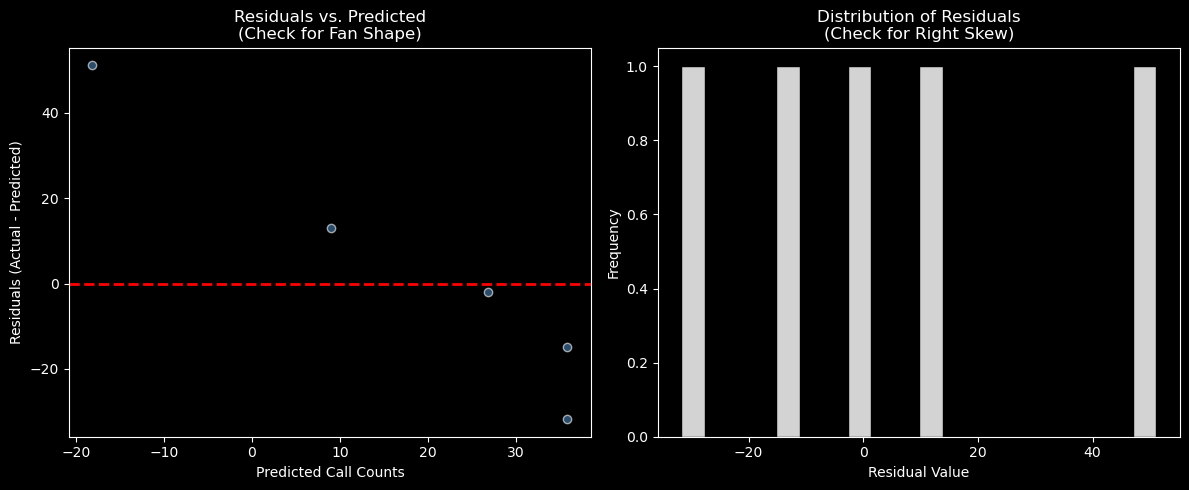

R-squared: -7.9239
Mean Absolute Error: 22.5316


In [23]:
X = merged_df[['Ozone', 'PM2.5', 'Diesel PM', 'Drinking Water', 'Lead',
               'Pesticides', 'Tox. Release', 'Traffic', 'Cleanup Sites', 
               'Groundwater Threats', 'Haz. Waste', 'Solid Waste']]
y = merged_df['call_count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
residuals = y_test - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(y_pred, residuals, alpha=0.6, color='steelblue', edgecolors='white')
ax1.axhline(0, color='red', linestyle='--', linewidth=2)
ax1.set_title("Residuals vs. Predicted\n(Check for Fan Shape)")
ax1.set_xlabel("Predicted Call Counts")
ax1.set_ylabel("Residuals (Actual - Predicted)")

ax2.hist(residuals, bins=20, color='lightgray', edgecolor='black')
ax2.set_title("Distribution of Residuals\n(Check for Right Skew)")
ax2.set_xlabel("Residual Value")
ax2.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.4f}")

## Divide by census tracts instead of zipcode

In [24]:
def assign_nearest_community(med_inc: pd.DataFrame,
                              communities: pd.DataFrame,
                              med_lat_col: str = 'latitude',
                              med_lon_col: str = 'longitude',
                              comm_lat_col: str = 'latitude',
                              comm_lon_col: str = 'longitude',
                              tract_col: str = 'Census_Tract') -> pd.DataFrame:
    """
    Assigns each medical incident to the nearest community region centroid
    using a vectorized cKDTree spatial join (fast, scales to millions of rows).
    """
    def to_radians_array(lat, lon):
        return np.radians(np.column_stack([lat, lon]))

    communities_clean = communities.dropna(subset=[comm_lat_col, comm_lon_col]).copy()
    med_inc_out = med_inc.copy()

    comm_coords_rad = to_radians_array(
        communities_clean[comm_lat_col].values,
        communities_clean[comm_lon_col].values
    )
    tree = cKDTree(comm_coords_rad)

    med_coords_rad = to_radians_array(
        med_inc_out[med_lat_col].values,
        med_inc_out[med_lon_col].values
    )

    valid_mask = ~(np.isnan(med_inc_out[med_lat_col].values) |
                   np.isnan(med_inc_out[med_lon_col].values))

    nearest_idx = np.full(len(med_inc_out), -1, dtype=int)
    _, nearest_idx[valid_mask] = tree.query(med_coords_rad[valid_mask], k=1)

    tract_values = communities_clean[tract_col].values
    med_inc_out['Census_Tract'] = np.where(
        nearest_idx >= 0,
        tract_values[nearest_idx],
        np.nan
    )

    n_unmatched = (nearest_idx == -1).sum()
    if n_unmatched > 0:
        print(f"{n_unmatched} rows had missing coordinates and were not assigned a tract.")
    print(f"Assigned Census_Tract to {valid_mask.sum():,} of {len(med_inc_out):,} medical incidents.")
    print(f"    Unique tracts assigned: {med_inc_out['Census_Tract'].nunique()}")

    return med_inc_out


def parse_point(point_str):
    """Parses a WKT POINT string into (latitude, longitude) as floats."""
    if pd.isna(point_str):
        return np.nan, np.nan
    match = re.search(r'POINT\s*\(\s*([-\d.]+)\s+([-\d.]+)\s*\)', str(point_str))
    if match:
        lon, lat = float(match.group(1)), float(match.group(2))
        return lat, lon
    return np.nan, np.nan


def extract_coords(med_inc: pd.DataFrame,
                   location_col: str = 'case_location') -> pd.DataFrame:
    """Adds '_latitude' and '_longitude' columns parsed from WKT POINT column."""
    med_inc = med_inc.copy()
    coords = med_inc[location_col].apply(parse_point)
    med_inc['_latitude'] = coords.apply(lambda x: x[0])
    med_inc['_longitude'] = coords.apply(lambda x: x[1])
    return med_inc

In [25]:
med_inc = extract_coords(med_inc, location_col='case_location')

med_inc = assign_nearest_community(
    med_inc=med_inc,
    communities=hazards,
    med_lat_col='_latitude',
    med_lon_col='_longitude',
    comm_lat_col='Latitude',
    comm_lon_col='Longitude',
    tract_col='Census Tract'
)

med_inc = med_inc.drop(columns=['_latitude', '_longitude'])

3 rows had missing coordinates and were not assigned a tract.
Assigned Census_Tract to 241,314 of 241,317 medical incidents.
    Unique tracts assigned: 198


In [26]:
med_inc

,Call Number,Unit ID,Incident Number,Call Type,Call Date,Received DtTm,Entry DtTm,Dispatch DtTm,Response DtTm,On Scene DtTm,...,Call Type Group,Number of Alarms,Unit Type,Unit sequence in call dispatch,Fire Prevention District,Supervisor District,Neighborhooods - Analysis Boundaries,RowID,case_location,Census_Tract
0,243661857,AM215,24183023,Medical Incident,12/31/2024,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,...,Non Life-threatening,1,BLS,1.0,3.0,5.0,Tenderloin,243661857-AM215,POINT (-122.411015164 37.78418755),6.075013e+09
3,243660212,E05,24182765,Medical Incident,12/31/2024,2024 Dec 31 03:17:09 AM,2024 Dec 31 03:18:29 AM,2024 Dec 31 03:18:36 AM,2024 Dec 31 03:20:52 AM,2024 Dec 31 03:22:55 AM,...,Potentially Life-Threatening,1,ENGINE,1.0,4.0,5.0,Japantown,243660212-E05,POINT (-122.434729992 37.784944006),6.075016e+09
4,243660148,M576,24182750,Medical Incident,12/31/2024,2024 Dec 31 02:06:51 AM,2024 Dec 31 02:09:38 AM,2024 Dec 31 02:10:26 AM,2024 Dec 31 02:10:33 AM,2024 Dec 31 02:23:11 AM,...,Potentially Life-Threatening,1,MEDIC,2.0,10.0,10.0,Bayview Hunters Point,243660148-M576,POINT (-122.367922359 37.727398351),6.075981e+09
9,243660207,KM107,24182764,Medical Incident,12/31/2024,2024 Dec 31 03:14:07 AM,2024 Dec 31 03:14:07 AM,2024 Dec 31 03:15:12 AM,2024 Dec 31 03:16:18 AM,2024 Dec 31 03:20:49 AM,...,Non Life-threatening,1,PRIVATE,1.0,2.0,5.0,Hayes Valley,243660207-KM107,POINT (-122.427913715 37.776253668),6.075016e+09
10,243660194,M580,24182763,Medical Incident,12/31/2024,2024 Dec 31 02:58:32 AM,2024 Dec 31 02:58:32 AM,2024 Dec 31 02:59:16 AM,2024 Dec 31 02:59:24 AM,2024 Dec 31 03:15:04 AM,...,Potentially Life-Threatening,1,MEDIC,1.0,9.0,11.0,Excelsior,243660194-M580,POINT (-122.439640305 37.716958531),6.075026e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368893,253643025,SCRT8,25186599,Medical Incident,12/30/2025,2025 Dec 30 08:48:09 PM,2025 Dec 30 08:48:09 PM,2025 Dec 30 08:48:23 PM,2025 Dec 30 08:48:27 PM,2025 Dec 30 09:06:45 PM,...,Potentially Life-Threatening,1,CP,1.0,5.0,8.0,Castro/Upper Market,253643025-SCRT8,POINT (-122.435187962 37.762670707),6.075020e+09
368894,253642315,M504,25186491,Medical Incident,12/30/2025,2025 Dec 30 04:42:27 PM,2025 Dec 30 04:43:05 PM,2025 Dec 30 04:45:12 PM,2025 Dec 30 04:45:25 PM,NaN,...,Potentially Life-Threatening,1,MEDIC,2.0,2.0,6.0,South of Market,253642315-M504,POINT (-122.410401493 37.778785373),6.075018e+09
368895,253640883,E08,25186295,Medical Incident,12/30/2025,2025 Dec 30 09:51:32 AM,2025 Dec 30 09:51:32 AM,2025 Dec 30 09:52:16 AM,2025 Dec 30 09:53:11 AM,2025 Dec 30 10:10:44 AM,...,Potentially Life-Threatening,1,ENGINE,2.0,3.0,6.0,South of Market,253640883-E08,POINT (-122.405847485 37.775231052),6.075018e+09
368897,253641114,KM110,25186338,Medical Incident,12/30/2025,2025 Dec 30 11:08:11 AM,2025 Dec 30 11:10:08 AM,2025 Dec 30 11:13:18 AM,2025 Dec 30 11:14:16 AM,2025 Dec 30 11:21:23 AM,...,Potentially Life-Threatening,1,PRIVATE,2.0,3.0,3.0,Financial District/South Beach,253641114-KM110,POINT (-122.393263731 37.794229821),6.075062e+09


In [27]:
med_inc['date_column'] = pd.to_datetime(med_inc['Call Date'], format='%m/%d/%Y')
d = date(2025, 1, 7)
med_inc_week = med_inc[med_inc['date_column'] < pd.Timestamp(d)]

/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_57273/1207893003.py:23: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  .centroid


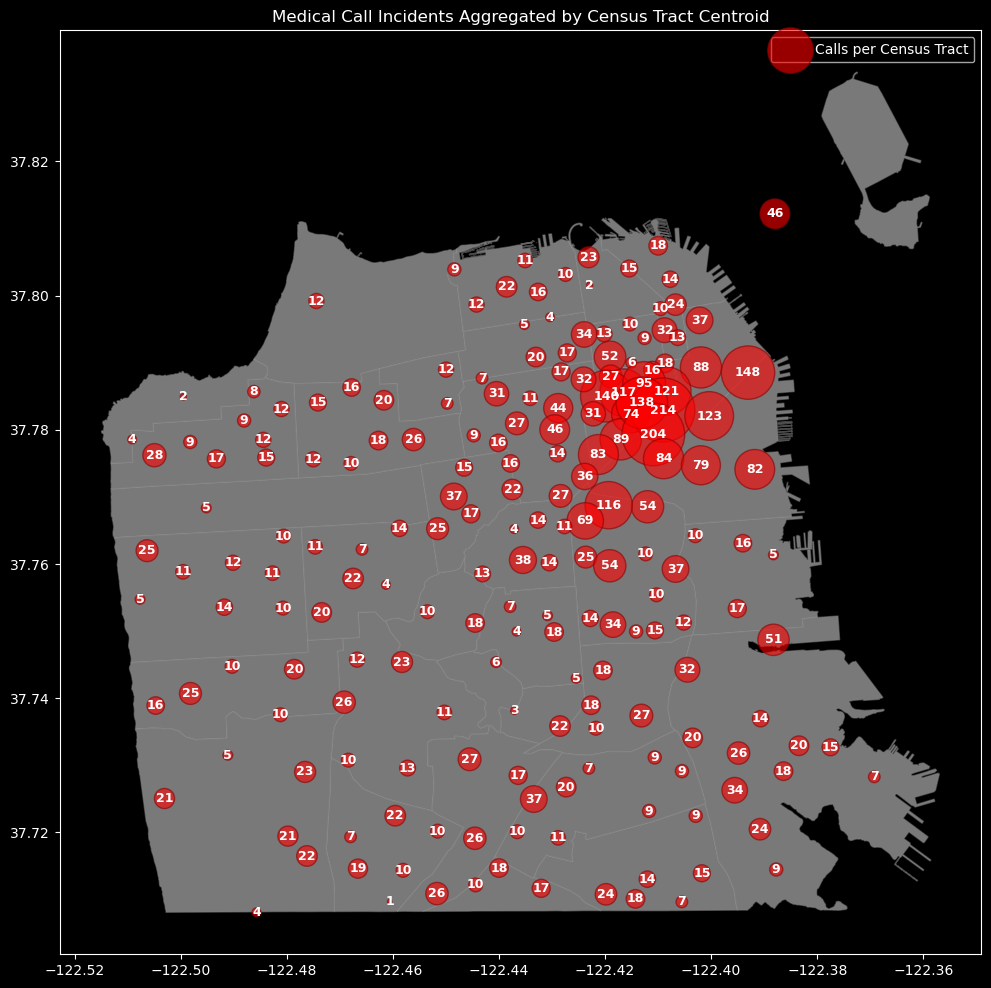

In [28]:
# 1. Load SF Map
sf_map = gpd.read_file('Planning_Neighborhood_Groups_Map_20260402.csv')
sf_map['geometry'] = sf_map['the_geom'].apply(wkt.loads)
sf_map = gpd.GeoDataFrame(sf_map, geometry='geometry', crs="EPSG:4326")

# 2. Prepare Medical Incidents
med_inc_week = med_inc_week.dropna(subset=['case_location'])
med_inc_week['geometry'] = med_inc_week['case_location'].apply(wkt.loads)
med_inc_gdf = gpd.GeoDataFrame(med_inc_week, geometry='geometry', crs="EPSG:4326")

# 3. Aggregate by Census_Tract
tract_counts = (
    med_inc_gdf
    .groupby('Census_Tract')
    .size()
    .reset_index(name='call_count')
)

# 4. Get Centroids per Census_Tract
tract_centroids = (
    med_inc_gdf
    .dissolve(by='Census_Tract')
    .centroid
)

tract_summary = gpd.GeoDataFrame(
    tract_counts,
    geometry=tract_centroids[tract_counts['Census_Tract']].values,
    crs="EPSG:4326"
)

# 5. Plotting
fig, ax = plt.subplots(figsize=(12, 12))
sf_map.plot(ax=ax, color='#f2f2f2', edgecolor='grey', alpha=0.5)

tract_summary.plot(
    ax=ax,
    color='red',
    markersize=tract_summary['call_count'] * 10,
    alpha=0.6,
    edgecolor='darkred',
    label='Calls per Census Tract'
)

for x, y, label in zip(tract_summary.geometry.x, tract_summary.geometry.y, tract_summary['call_count']):
    ax.text(x, y, str(label), fontsize=9, fontweight='bold', ha='center', va='center')

plt.title('Medical Call Incidents Aggregated by Census Tract Centroid')
plt.legend()
plt.show()

## Aggregate by 3-month periods: mean & std of calls/week per tract

In [29]:
med_inc['date_column'] = pd.to_datetime(med_inc['Call Date'], format='%m/%d/%Y')
med_inc['month'] = med_inc['date_column'].dt.month
med_inc['iso_week'] = med_inc['date_column'].dt.isocalendar().week.astype(int)

def period_label(m):
    if m in (11, 12, 1):
        return 'nov_jan'
    elif m in (2, 3, 4):
        return 'feb_apr'
    elif m in (5, 6, 7):
        return 'may_jul'
    else:
        return 'aug_oct'

med_inc['period'] = med_inc['month'].map(period_label)

# weekly call counts per tract per week
weekly = (
    med_inc.groupby(['Census_Tract', 'period', 'iso_week'])
    .size()
    .reset_index(name='calls_that_week')
)

# aggregate to mean & std per tract per period
period_stats = (
    weekly.groupby(['Census_Tract', 'period'])['calls_that_week']
    .agg(['mean', 'std'])
    .reset_index()
)

# pivot wide: one row per tract, columns per period
period_stats['mean'] = period_stats['mean'].round(2)
period_stats['std'] = period_stats['std'].round(2)

mean_wide = period_stats.pivot(index='Census_Tract', columns='period', values='mean')
mean_wide.columns = [f'call_avg_{c}' for c in mean_wide.columns]

std_wide = period_stats.pivot(index='Census_Tract', columns='period', values='std')
std_wide.columns = [f'call_std_{c}' for c in std_wide.columns]

period_cols = mean_wide.join(std_wide).reset_index()
period_cols['Census_Tract'] = period_cols['Census_Tract'].astype(int)

In [30]:
hazards_sf = hazards[hazards['California County']=='San Francisco'].copy()
hazards_sf['Census_Tract'] = hazards_sf['Census Tract'].astype(int)

merged_periods = hazards_sf.merge(period_cols, on='Census_Tract', how='inner')
print(f"Rows (tracts): {merged_periods.shape[0]}, Columns: {merged_periods.shape[1]}")
merged_periods[[c for c in merged_periods.columns if 'call_' in c or c == 'Census_Tract']].head()

Rows (tracts): 194, Columns: 67


,Census_Tract,call_avg_aug_oct,call_avg_feb_apr,call_avg_may_jul,call_avg_nov_jan,call_std_aug_oct,call_std_feb_apr,call_std_may_jul,call_std_nov_jan
0,6075023200,27.86,25.86,25.79,27.86,7.99,10.20,9.97,13.85
1,6075023103,18.21,13.86,17.29,17.00,8.29,7.03,8.77,7.42
2,6075023001,13.64,9.92,12.50,15.77,5.60,4.07,6.12,6.51
3,6075023400,15.43,20.64,20.64,16.57,7.08,8.04,8.94,6.35
4,6075023102,22.08,22.64,19.57,22.07,8.27,11.08,6.55,8.12


In [31]:
merged_periods

,Census Tract,Total Population,California County,ZIP,Approximate Location,Longitude,Latitude,CES 4.0 Score,CES 4.0 Percentile,CES 4.0 Percentile Range,...,Pop. Char. Pctl,Census_Tract,call_avg_aug_oct,call_avg_feb_apr,call_avg_may_jul,call_avg_nov_jan,call_std_aug_oct,call_std_feb_apr,call_std_may_jul,call_std_nov_jan
0,6075023200,3972,San Francisco,94124,San Francisco,-122.386139,37.727755,54.605674,92.208775,90-95%,...,85.388301,6075023200,27.86,25.86,25.79,27.86,7.99,10.20,9.97,13.85
1,6075023103,2890,San Francisco,94124,San Francisco,-122.375965,37.735632,50.508864,88.401412,85-90%,...,83.787191,6075023103,18.21,13.86,17.29,17.00,8.29,7.03,8.77,7.42
2,6075023001,5398,San Francisco,94124,San Francisco,-122.401760,37.735192,49.329481,87.191125,85-90%,...,82.299546,6075023001,13.64,9.92,12.50,15.77,5.60,4.07,6.12,6.51
3,6075023400,3661,San Francisco,94124,San Francisco,-122.390088,37.721593,46.984298,84.404942,80-85%,...,78.328290,6075023400,15.43,20.64,20.64,16.57,7.08,8.04,8.94,6.35
4,6075023102,4549,San Francisco,94124,San Francisco,-122.384498,37.734492,46.932707,84.329299,80-85%,...,87.304589,6075023102,22.08,22.64,19.57,22.07,8.27,11.08,6.55,8.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,6075021600,4135,San Francisco,94131,San Francisco,-122.438142,37.745496,2.604107,0.491679,1-5% (lowest scores),...,1.550681,6075021600,6.79,6.50,10.23,8.79,4.34,3.99,5.00,3.26
190,6075021300,2590,San Francisco,94114,San Francisco,-122.438468,37.749265,1.654782,0.113464,1-5% (lowest scores),...,0.189107,6075021300,3.45,2.89,3.50,2.43,2.38,2.09,1.73,0.98
191,6075980200,312,San Francisco,94121,San Francisco,-122.502826,37.786069,NaN,NaN,NaN,...,NaN,6075980200,2.29,3.50,3.50,2.25,1.60,0.71,2.43,1.16
192,6075980300,63,San Francisco,94122,San Francisco,-122.492087,37.768403,NaN,NaN,NaN,...,NaN,6075980300,6.54,6.75,5.00,4.83,2.54,5.06,3.10,3.38
